# Triplet lifetime monitoring for Xenon-Doping Study (Liq. #7)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.fft import fft, ifft
import pandas as pd
import glob
import sipm.util.functions as func
from datetime import datetime
from scipy.optimize import least_squares
plt.style.use('darkside')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [4]:
!pwd

/home/as111/sipm-analysis/jupyter


# SPE Pulse Shape
Laser waveform is 4000 samples long (16us) while scintillation waveform is 5000 samples long (20us) in liq. 7. Need to extend the laser waveform.

In [5]:
# data folder
path = "/scratch/gpfs/GALBIATI/as111/results/2023-12-13"
data_spe = {}
channels = np.arange(8)
volt = 98
for ch in channels:
    data_spe[ch] = {'n_spe_wfs':0, 'avg_spe_wf':np.zeros(0), 'time':np.zeros(0)}
    files = glob.glob(f"{path}/*volt_{volt}*laser_waveform_liq5.h5")
    print(files)
    for f in files:
        df = pd.read_hdf(f, key=f'{volt}/{ch}')
        data_spe[ch]['n_spe_wfs'] += np.array(df['n_spe_wfs'])[0]
        if data_spe[ch]['time'].shape[0]==0:
            data_spe[ch]['time'] = np.array(df['time'])
        if np.array(df['n_spe_wfs'])[0]>0:
            if data_spe[ch]['avg_spe_wf'].shape[0]==0:
                data_spe[ch]['avg_spe_wf'] = np.array(df['avg_spe_wf'])*np.array(df['n_spe_wfs'])[0]
            else:
                data_spe[ch]['avg_spe_wf'] += np.array(df['avg_spe_wf'])*np.array(df['n_spe_wfs'])[0]
    df = None
    if data_spe[ch]['n_spe_wfs']>0:
        data_spe[ch]['avg_spe_wf'] /= data_spe[ch]['n_spe_wfs']
    # extend laser waveform from 4000 samp to 5000 samp
    data_spe[ch]['time'] = np.concatenate([data_spe[ch]['time'],np.arange(4000,5000,1)*0.004])
    data_spe[ch]['avg_spe_wf'] = np.concatenate([data_spe[ch]['avg_spe_wf'],np.zeros(1000)])
    

['/scratch/gpfs/GALBIATI/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run0_laser_waveform_liq5.h5', '/scratch/gpfs/GALBIATI/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run5_laser_waveform_liq5.h5', '/scratch/gpfs/GALBIATI/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run3_laser_waveform_liq5.h5', '/scratch/gpfs/GALBIATI/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run4_laser_waveform_liq5.h5', '/scratch/gpfs/GALBIATI/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run8_laser_waveform_liq5.h5', '/scratch/gpfs/GALBIATI/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run2_laser_waveform_liq5.h5', '/scratch/gpfs/GALBIATI/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run9_laser_waveform_liq5.h5', '/scratch/gpfs/GALBIATI/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run6_laser_waveform_liq5.h5', '/scratch/gpfs/GALBIATI/as111/results/2023-12-13/2023-1

ch0 98V 52313 waveforms selected
ch1 98V 81455 waveforms selected
ch2 98V 71758 waveforms selected
ch3 98V 93199 waveforms selected
ch4 98V 97203 waveforms selected
ch5 98V 80383 waveforms selected
ch6 98V 35771 waveforms selected
ch7 98V 30426 waveforms selected


Text(0.07, 0.5, 'Amplitude (ADC Unit)')

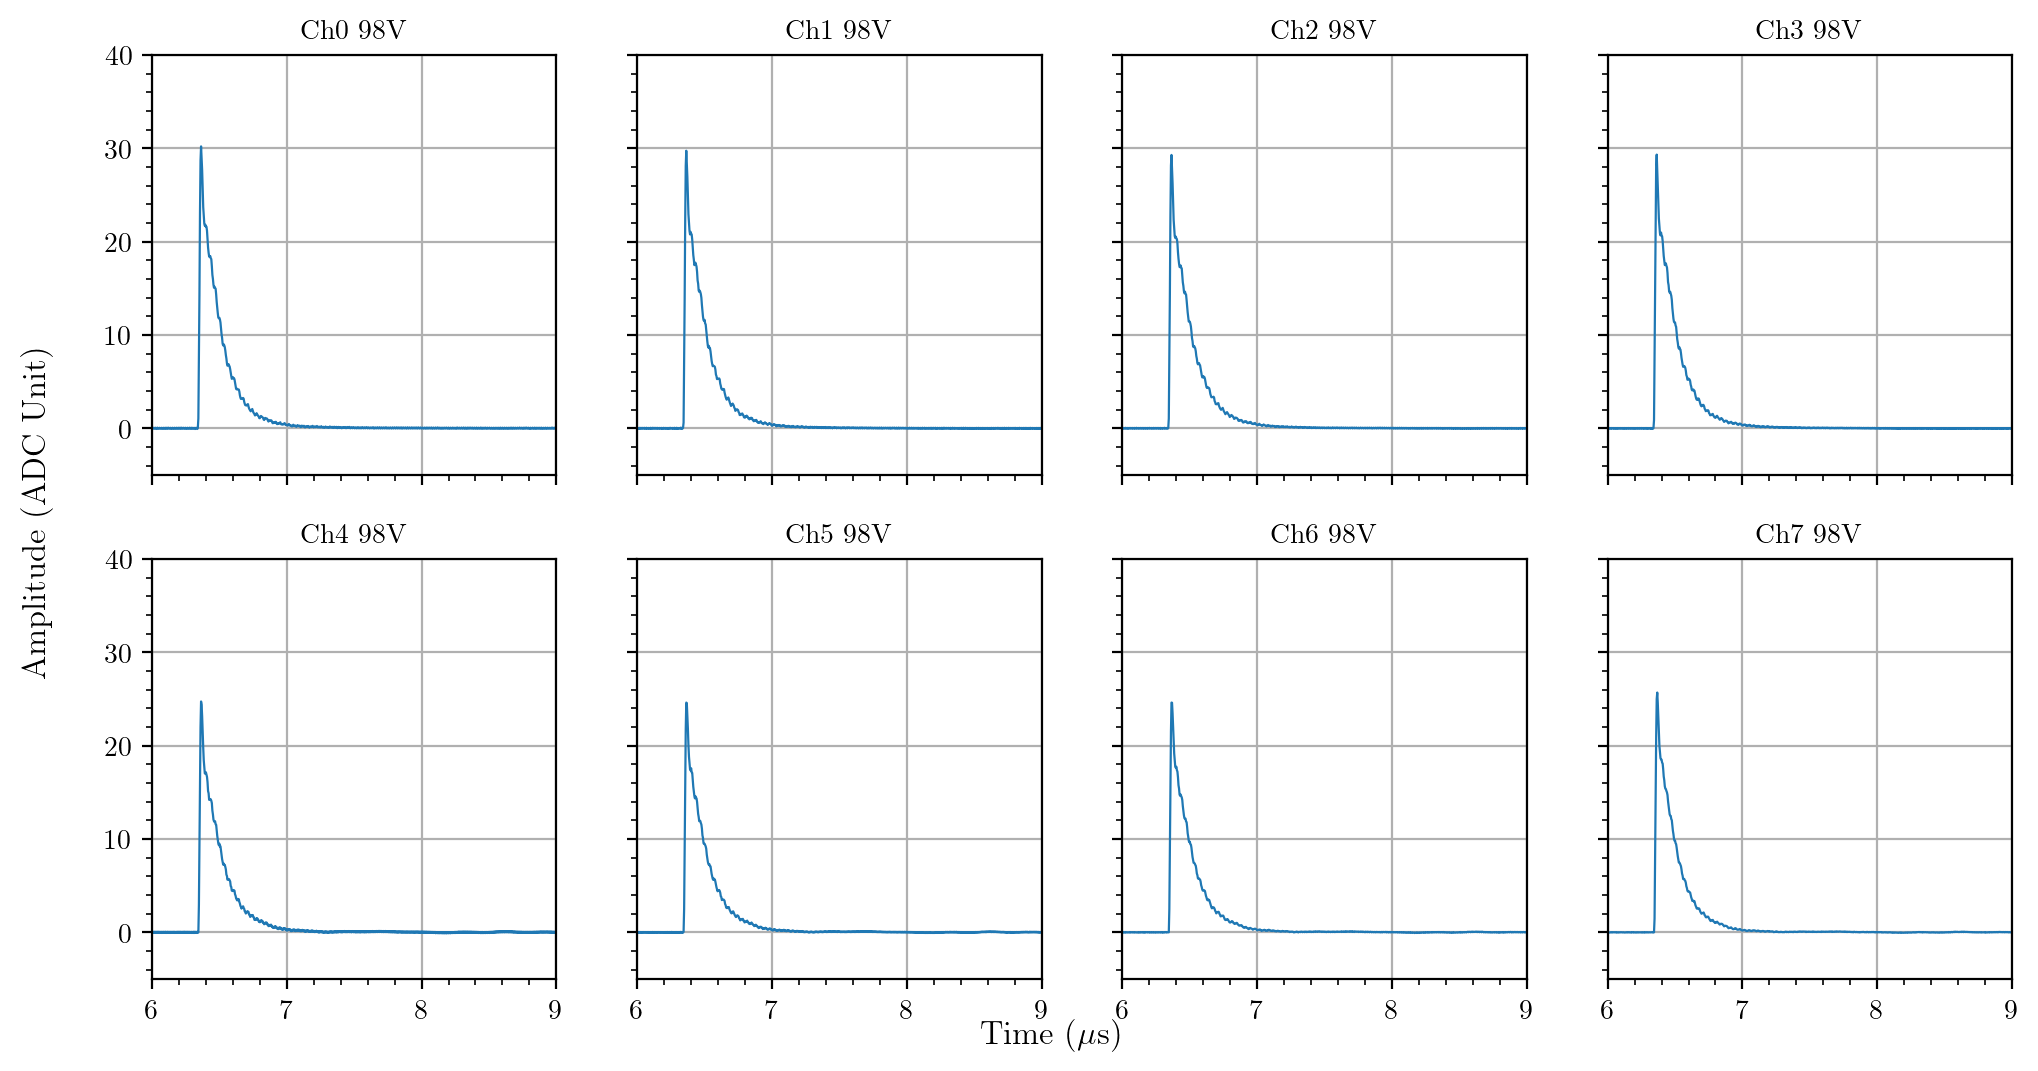

In [7]:
# Make plots for all datasets
# SPE average waveform
t0 = 6.34
fig, axs = plt.subplots(2, 4, sharex=True, sharey=True)
fig.set_size_inches(12, 6)
for j, ch in enumerate(channels):
    if data_spe[ch]['n_spe_wfs']>0:
        print(f'ch{ch} {volt}V {data_spe[ch]["n_spe_wfs"]:.0f} waveforms selected')
        axs[j//4, j%4].plot(
            data_spe[ch]['time'],
            data_spe[ch]['avg_spe_wf'],linewidth=0.8)
    axs[j//4, j%4].set_xlim(6, 9)
    axs[j//4, j%4].set_ylim(-5, 40)
    # axs[j//4, j%4].set_yscale('log')
    axs[j//4, j%4].minorticks_on()
    axs[j//4, j%4].grid()
    axs[j//4, j%4].set_title(f'Ch{ch} {volt}V')
fig.supxlabel(r'Time ($\mu$s)', y=0.05)
fig.supylabel(r'Amplitude (ADC Unit)', x=0.07)

## FFT

Text(0.07, 0.5, 'FFT Abs. Amplitude (ADC Unit)')

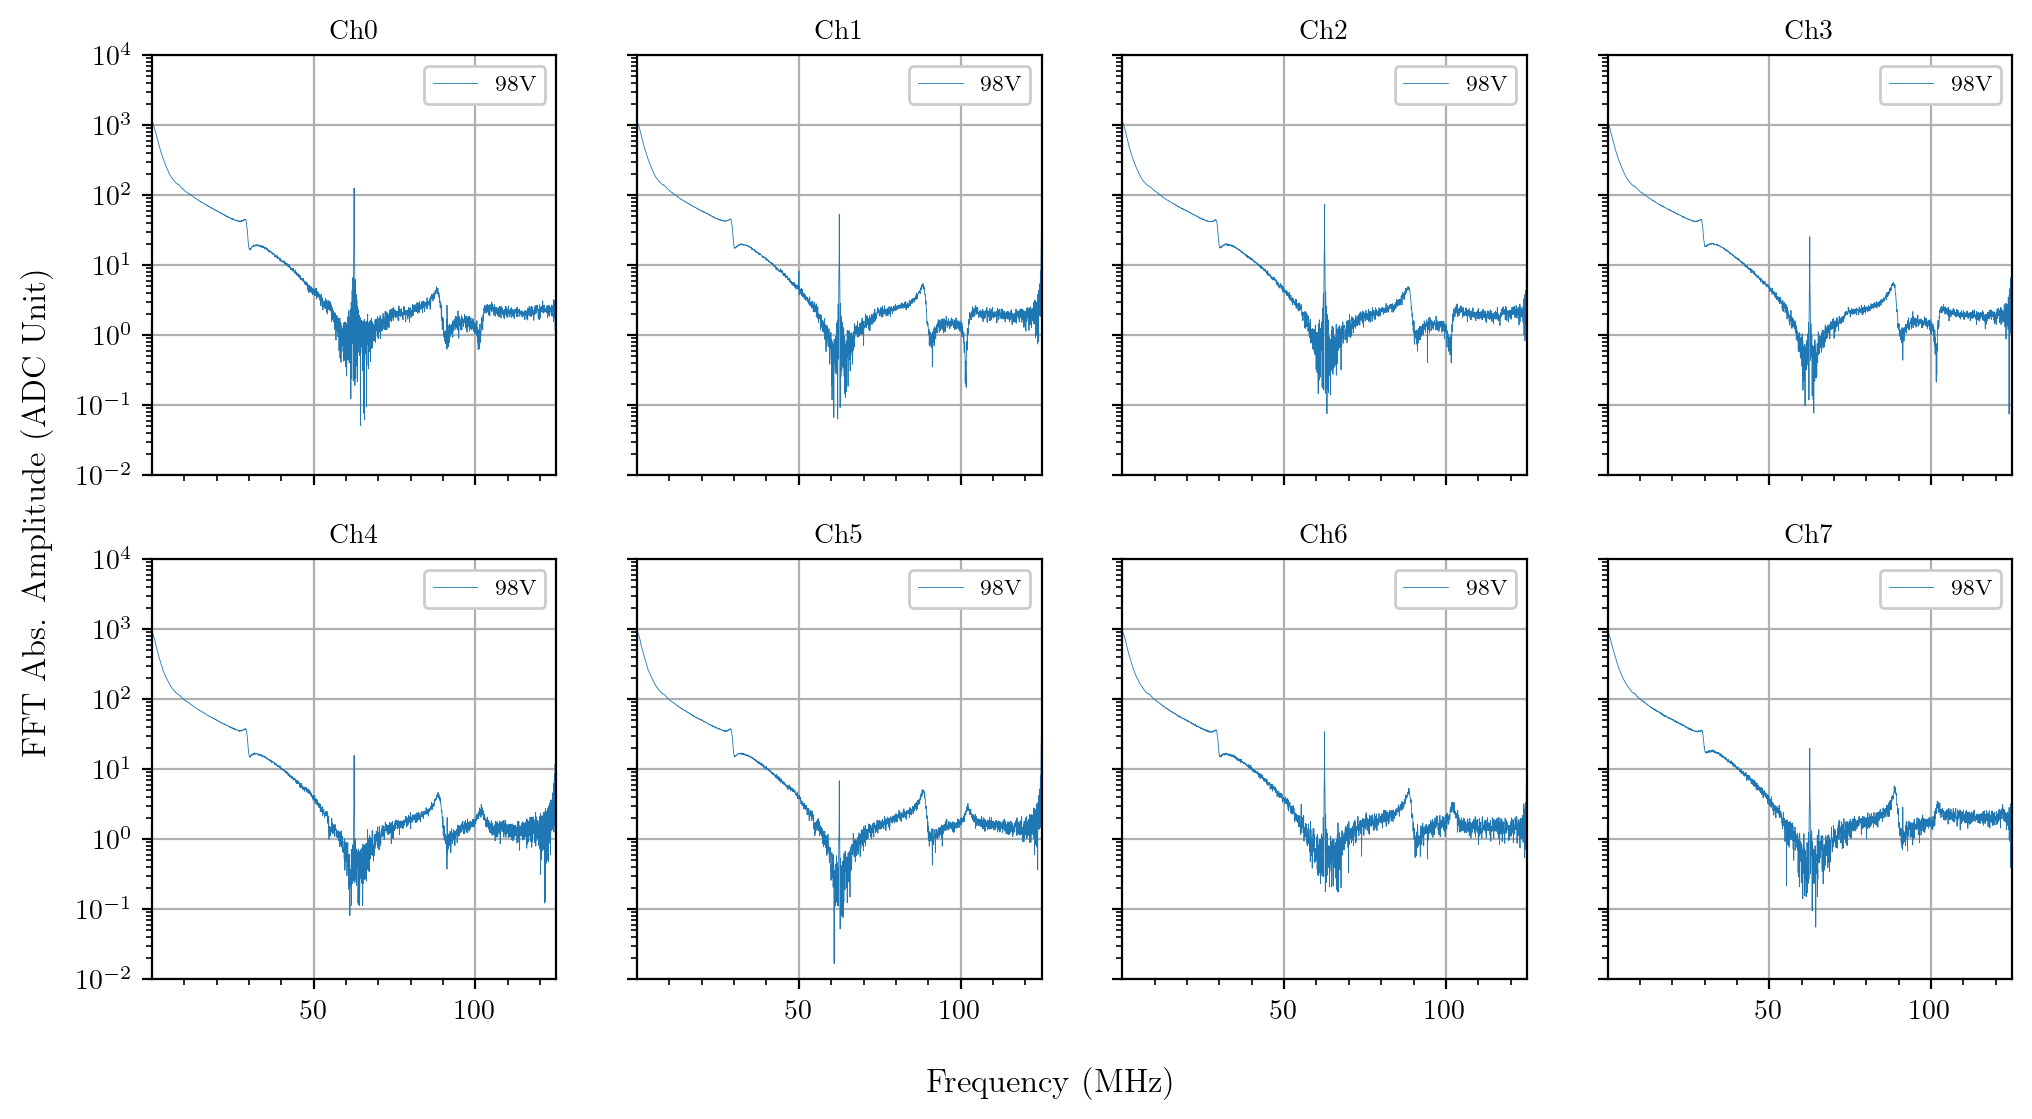

In [8]:
# Make plots for all datasets
# SPE average waveform
fig, axs = plt.subplots(2, 4, sharex=True, sharey=True)
fig.set_size_inches(12, 6)
for j, ch in enumerate(channels):
    data_spe[ch]['fft_spe_wf'] = fft(data_spe[ch]['avg_spe_wf'])
    dt = data_spe[ch]['time'][1]-data_spe[ch]['time'][0]
    t_total = dt+data_spe[ch]['time'][-1]
    n_over_2 = int(data_spe[ch]['time'].shape[0]/2)
    data_spe[ch]['frequency'] = data_spe[ch]['time']/dt/t_total
    axs[j//4, j%4].plot(
        data_spe[ch]['frequency'][:n_over_2],
        abs(data_spe[ch]['fft_spe_wf'][:n_over_2]),
        label=f'{volt}V', linewidth=0.3)
    axs[j//4, j%4].legend(loc='upper right')
    axs[j//4, j%4].set_xlim(data_spe[ch]['frequency'][1], data_spe[ch]['frequency'][n_over_2])
    axs[j//4, j%4].set_ylim(1e-2, 1e4)
    axs[j//4, j%4].set_yscale('log')
    axs[j//4, j%4].minorticks_on()
    axs[j//4, j%4].grid()
    axs[j//4, j%4].set_title(f'Ch{ch}')
fig.supxlabel(r'Frequency (MHz)', y=0.01)
fig.supylabel(r'FFT Abs. Amplitude (ADC Unit)', x=0.07)

# Triplet lifetime

Average over events $\rightarrow$ deconvolution $\rightarrow$ sum over channels (WL/WW separately) $\rightarrow$ exponential fit

In [9]:
S_PER_HR = 3600
dt_getter = datetime(2024,4,18,15,43,0)
print('The getter was turned on at', dt_getter)

The getter was turned on at 2024-04-18 15:43:00


In [10]:
# Pure LAr
path = "/scratch/gpfs/GALBIATI/as111/results/"
dates = ['2024-04-19','2024-04-26']
files = []
for d in dates:
    files.extend(glob.glob(f"{path}{d}/*xenon_0*scintillation_waveform_liq7.h5"))
for i,f in enumerate(files):
    files[i] = [files[i]]
print(files)
print(len(files))

[['/scratch/gpfs/GALBIATI/as111/results/2024-04-19/2024-04-19_volt_98_light_scintillation_cond_monitor_source_co60_xenon_0_run1_scintillation_waveform_liq7.h5'], ['/scratch/gpfs/GALBIATI/as111/results/2024-04-19/2024-04-19_volt_98_light_scintillation_cond_monitor_source_co60_xenon_0_run21_scintillation_waveform_liq7.h5'], ['/scratch/gpfs/GALBIATI/as111/results/2024-04-19/2024-04-19_volt_98_light_scintillation_cond_monitor_source_co60_xenon_0_run6_scintillation_waveform_liq7.h5'], ['/scratch/gpfs/GALBIATI/as111/results/2024-04-19/2024-04-19_volt_98_light_scintillation_cond_monitor_source_co60_xenon_0_run12_scintillation_waveform_liq7.h5'], ['/scratch/gpfs/GALBIATI/as111/results/2024-04-19/2024-04-19_volt_98_light_scintillation_cond_monitor_source_co60_xenon_0_run14_scintillation_waveform_liq7.h5'], ['/scratch/gpfs/GALBIATI/as111/results/2024-04-19/2024-04-19_volt_98_light_scintillation_cond_monitor_source_co60_xenon_0_run37_scintillation_waveform_liq7.h5'], ['/scratch/gpfs/GALBIATI/as11

In [11]:
# data folder
data_scint = {}
date_time = {}
channels = np.arange(8)
channels_nofs = [1,2,4,7] 
channels_fs = [0,3,5,6]
ch_old = [0,5,6,3,4,1,2,7] # map to channels in liq5 calibration data
volt = 98
for i,fs in enumerate(files):
    data_scint[i] = {}
    for j,f in enumerate(fs):
        df = pd.read_hdf(f, key=f'{volt}/-1')
        if j==0:
            date_time[i] = datetime(*np.array(df['start_datetime'][:6]).astype(int))
        for ch in channels:
            if j==0:
                data_scint[i][ch] = {'n_scint_wfs':0, 'avg_scint_wf':np.zeros(0), 'time':np.zeros(0)}
            df = pd.read_hdf(f, key=f'{volt}/{ch}')
            data_scint[i][ch]['n_scint_wfs'] += np.array(df['n_scint_wfs'])[0]
            if data_scint[i][ch]['time'].shape[0]==0:
                data_scint[i][ch]['time'] = np.array(df['time'].dropna())
            if data_scint[i][ch]['avg_scint_wf'].shape[0]==0:
                data_scint[i][ch]['avg_scint_wf'] = np.array(df['avg_scint_wf'].dropna())*np.array(df['n_scint_wfs'])[0]
            else:
                data_scint[i][ch]['avg_scint_wf'] += np.array(df['avg_scint_wf'].dropna())*np.array(df['n_scint_wfs'])[0]
            df = None
            data_scint[i][ch]['avg_scint_wf'] /= data_scint[i][ch]['n_scint_wfs']
# sort according to date time
args = np.array(list(date_time.values())).argsort()
files = [files[i] for i in args]
data_scint = [data_scint[i] for i in args]
date_time = [date_time[i] for i in args]
# hr_from_inject = [(dt-dt_xe[0]).total_seconds()/S_PER_HR for dt in date_time]
hr_from_getter = [(dt-dt_getter).total_seconds()/S_PER_HR for dt in date_time]

2024-04-19 12:03:49 ch0 13769 waveforms selected
2024-04-19 16:07:11 ch0 13643 waveforms selected
2024-04-19 20:10:40 ch0 13558 waveforms selected
2024-04-20 00:14:02 ch0 13575 waveforms selected
2024-04-20 04:17:29 ch0 13450 waveforms selected
2024-04-20 08:20:53 ch0 13477 waveforms selected
2024-04-20 12:24:19 ch0 13280 waveforms selected
2024-04-20 16:27:44 ch0 13416 waveforms selected
2024-04-20 20:31:10 ch0 13351 waveforms selected
2024-04-21 00:34:35 ch0 13378 waveforms selected
2024-04-21 04:37:59 ch0 13188 waveforms selected
2024-04-21 08:41:19 ch0 13112 waveforms selected
2024-04-21 12:44:39 ch0 13239 waveforms selected
2024-04-21 16:48:01 ch0 13246 waveforms selected
2024-04-21 20:51:26 ch0 13043 waveforms selected
2024-04-22 00:54:48 ch0 13054 waveforms selected
2024-04-22 04:58:10 ch0 12918 waveforms selected
2024-04-22 09:01:32 ch0 12998 waveforms selected
2024-04-22 13:04:55 ch0 12943 waveforms selected
2024-04-22 17:08:15 ch0 12975 waveforms selected
2024-04-22 21:11:36 

Text(0.07, 0.5, 'Amplitude (ADC Unit)')

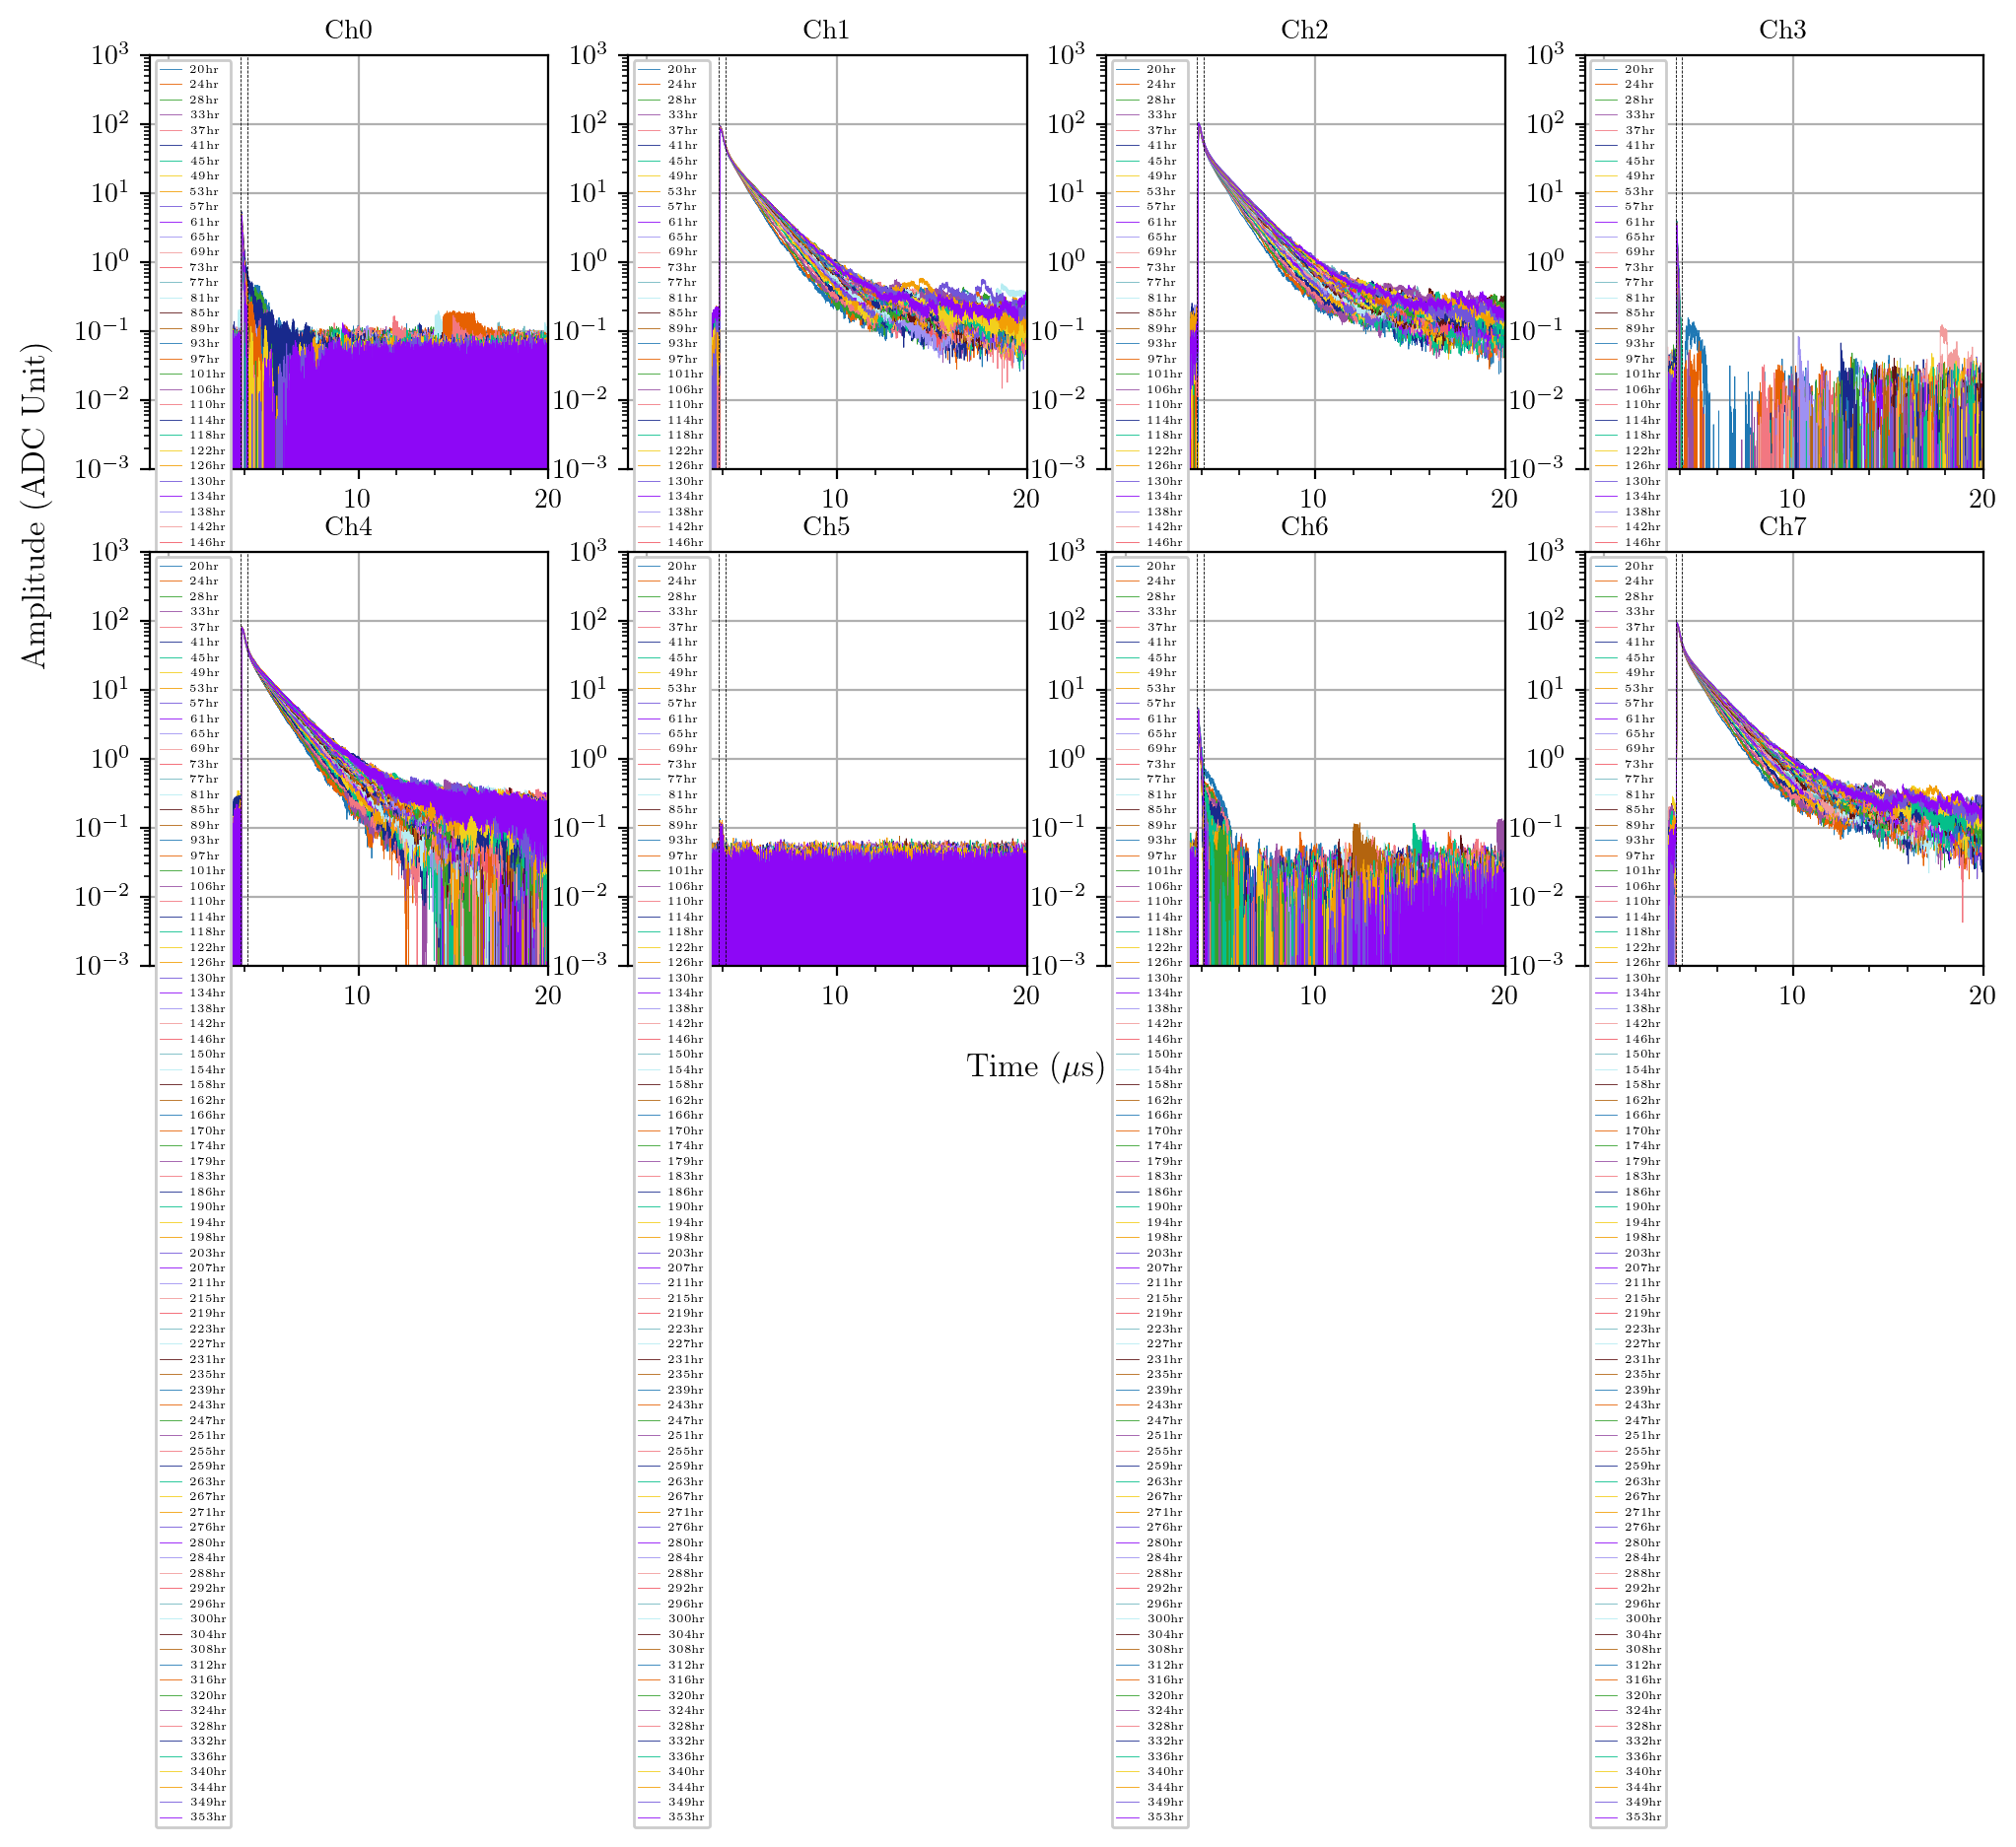

In [12]:
# Make plots for all datasets
# Average LAr scintillation waveform
t_trig = 3.82
ylims = (1e-3,1e3)
fig, axs = plt.subplots(2, 4, sharex=False, sharey=False)
fig.set_size_inches(12, 6)
for j, ch in enumerate(channels):
    for k, f in enumerate(files):
        print(f'{date_time[k]} ch{ch} {data_scint[k][ch]["n_scint_wfs"]:.0f} waveforms selected')
        axs[j//4, j%4].plot(
            data_scint[k][ch]['time'],
            data_scint[k][ch]['avg_scint_wf'],
            label=f'{hr_from_getter[k]:.0f}hr', color=f'C{k}', linewidth=0.3)
            # label=f'{hr_from_inject[k]:.0f}hr', color=f'C{k}', linewidth=0.3)
    axs[j//4, j%4].legend(loc='upper left',fontsize=4)
    axs[j//4, j%4].set_xlim(-1, 20)
    axs[j//4, j%4].set_ylim(*ylims)
    axs[j//4, j%4].set_yscale('log')
    axs[j//4, j%4].minorticks_on()
    axs[j//4, j%4].grid()
    axs[j//4, j%4].set_title(f'Ch{ch}')
    axs[j//4, j%4].plot([t_trig-10*0.004]*2, ylims, 'k--',linewidth=0.3)
    axs[j//4, j%4].plot([t_trig+0.3]*2, ylims, 'k--',linewidth=0.3)
fig.supxlabel(r'Time ($\mu$s)', y=0.01)
fig.supylabel(r'Amplitude (ADC Unit)', x=0.07)

## Deconvolution

In [13]:
# Deconvolution channel by channel
for i, f in enumerate(files):
    for j, ch in enumerate(channels):
        if data_scint[i][ch]['n_scint_wfs']>0 and data_spe[ch_old[ch]]['n_spe_wfs']>0:
            dt = data_spe[ch_old[ch]]['time'][1]-data_spe[ch_old[ch]]['time'][0]
            shift = np.array([np.exp(complex(0,-2*np.pi*freq*dt*int(t0/dt))) for freq in data_spe[ch_old[ch]]['frequency']])
            data_scint[i][ch]['deconv'] = ifft(fft(data_scint[i][ch]['avg_scint_wf'])/data_spe[ch_old[ch]]['fft_spe_wf']*shift).real

Text(0.07, 0.5, 'Amplitude (ADC Unit)')

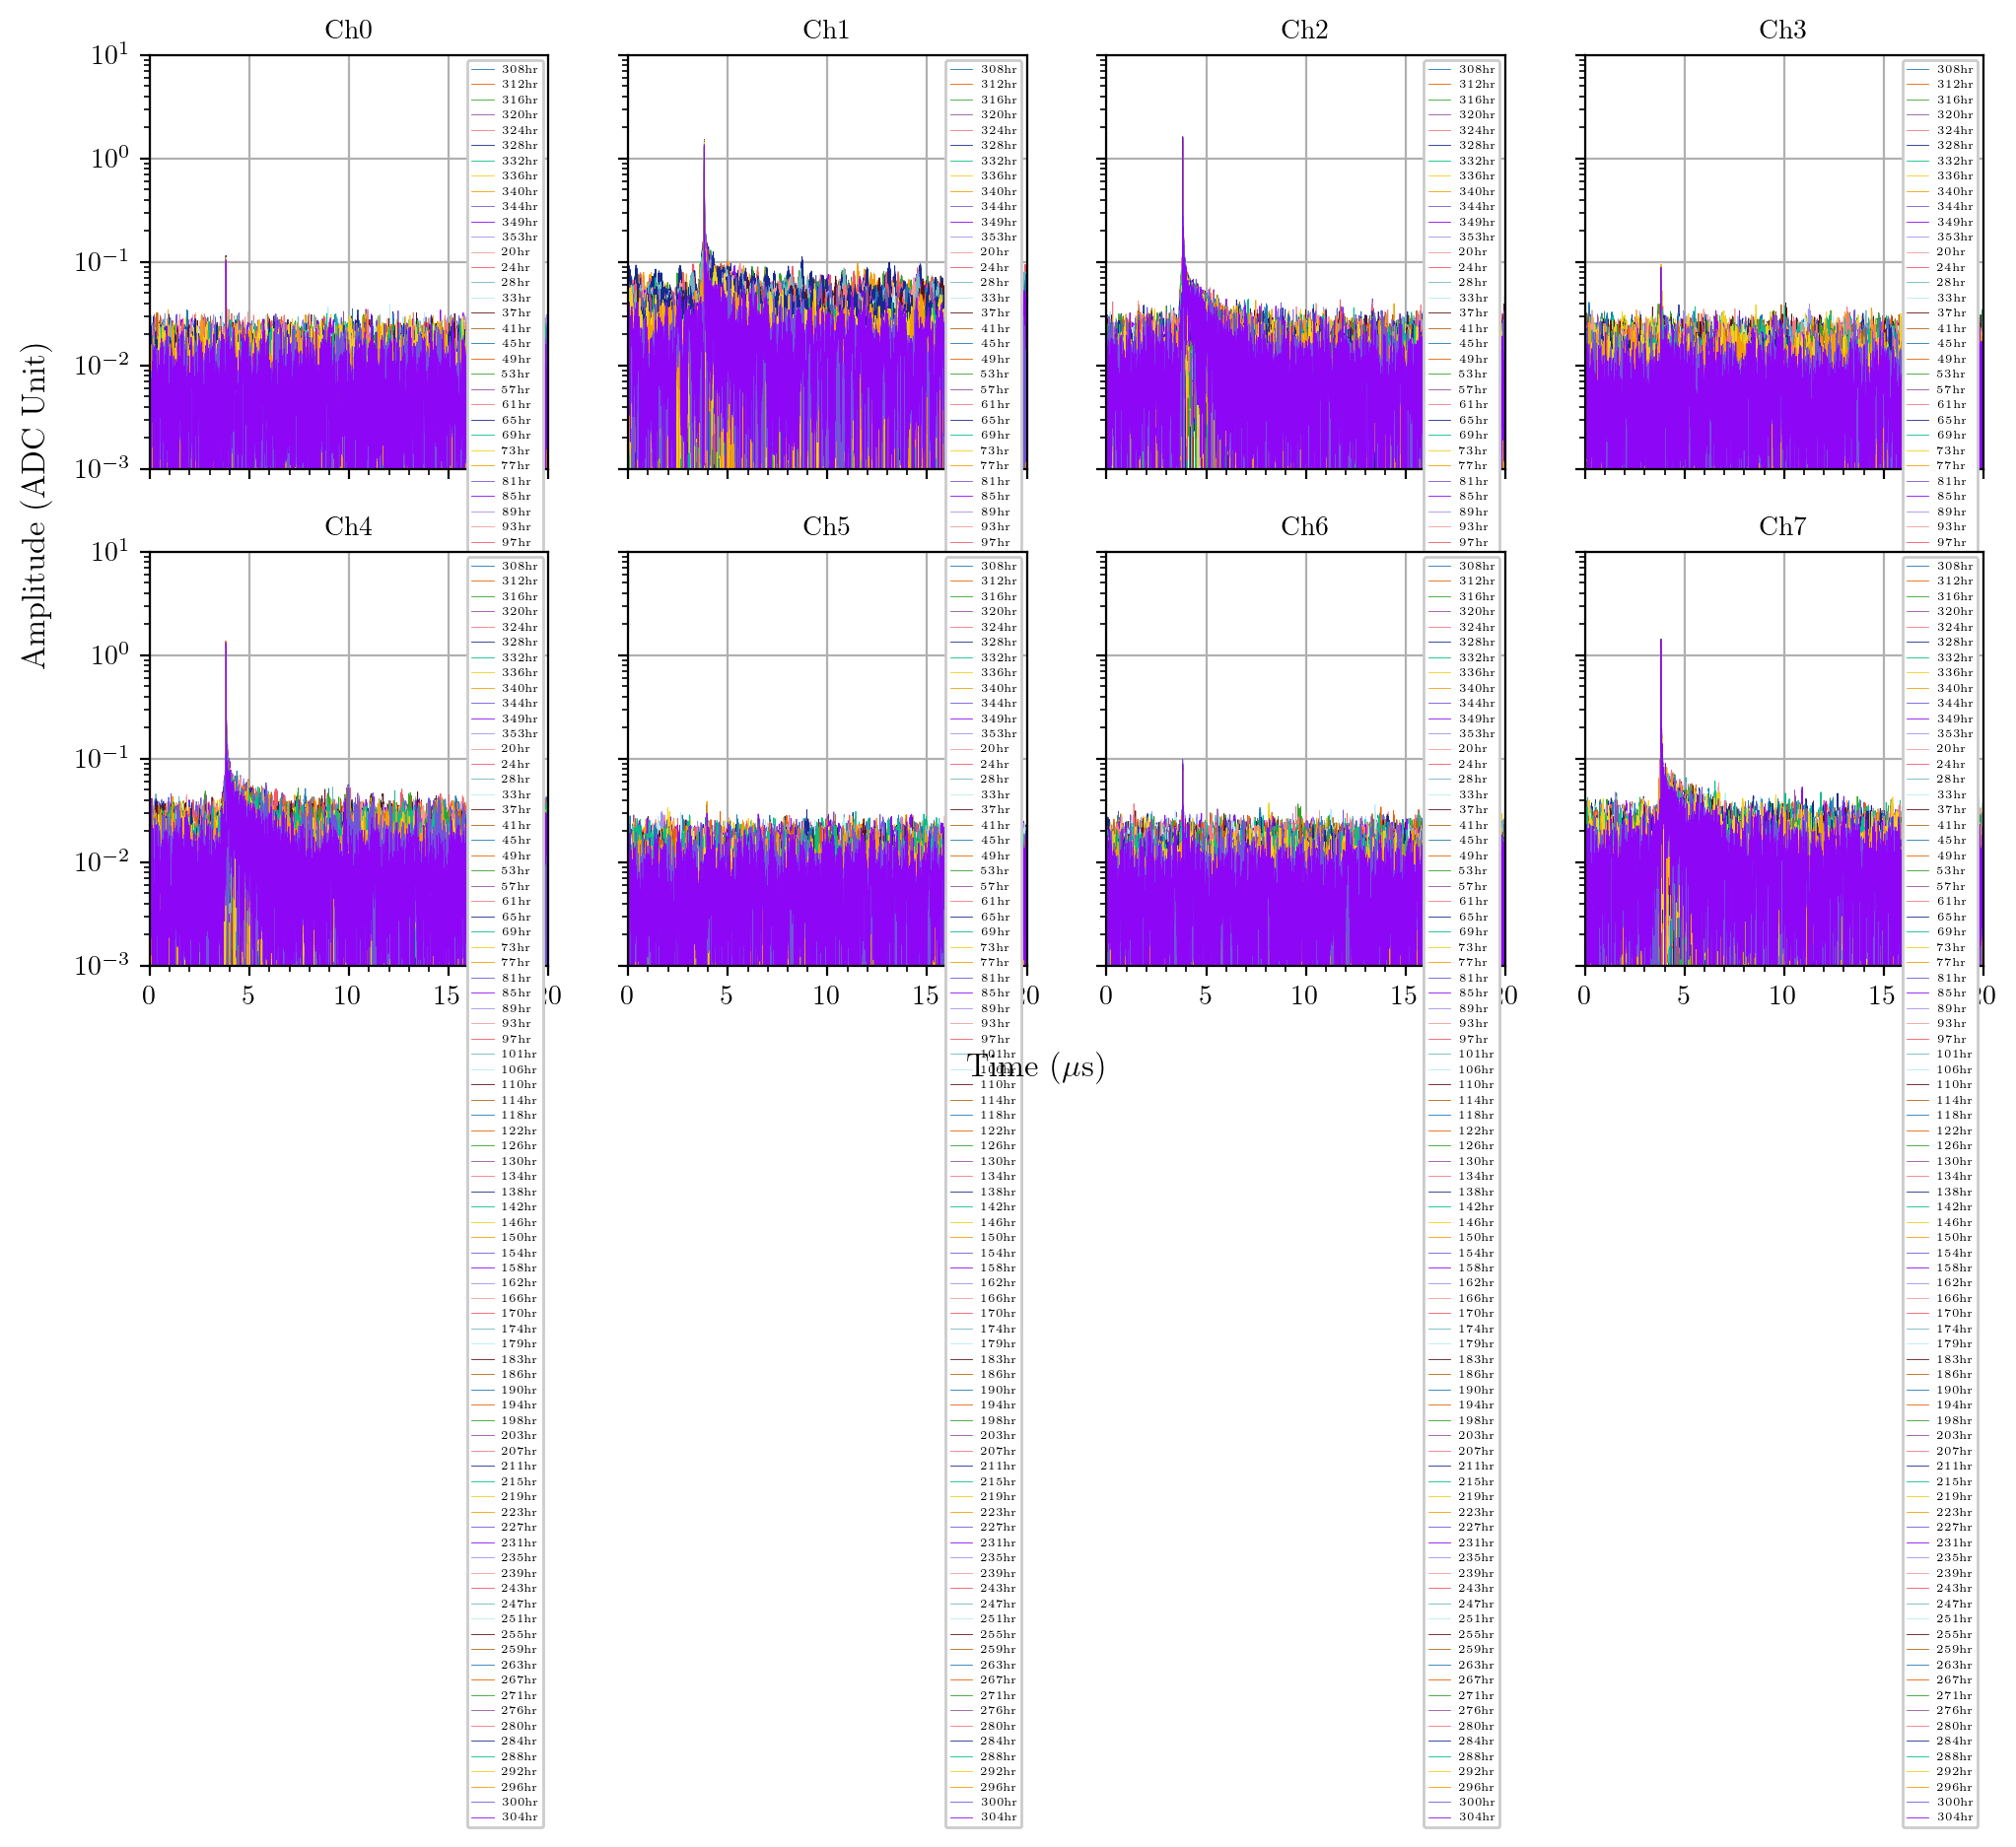

In [14]:
# Make plots for all datasets
# Deconvolved scintillation waveform
fig, axs = plt.subplots(2, 4, sharex=True, sharey=True)
fig.set_size_inches(12, 6)
for j, ch in enumerate(channels):
    for k, f in enumerate(files):
        if data_scint[k][ch]['n_scint_wfs']>0 and data_spe[ch]['n_spe_wfs']>0:
            axs[j//4, j%4].plot(
                data_scint[k][ch]['time'],
                abs(data_scint[k][ch]['deconv']),
                label=f'{hr_from_getter[-12+k]:.0f}hr', color=f'C{k}', linewidth=0.3)
                # label=f'{hr_from_inject[k]:.0f}hr', color=f'C{k}', linewidth=0.3)
    axs[j//4, j%4].legend(loc='upper right', fontsize=4)
    axs[j//4, j%4].set_xlim(0, 20)
    axs[j//4, j%4].set_ylim(1e-3, 1e1)
    axs[j//4, j%4].set_yscale('log')
    axs[j//4, j%4].minorticks_on()
    axs[j//4, j%4].grid()
    axs[j//4, j%4].set_title(f'Ch{ch}')
fig.supxlabel(r'Time ($\mu$s)', y=0.01)
fig.supylabel(r'Amplitude (ADC Unit)', x=0.07)

## Summation + Subsampling

In [15]:
# summation
for i,f in enumerate(files):
    data_scint[i][-1] = {'time': data_scint[i][0]['time'], 'sum_wf_nofs': np.zeros(data_scint[i][0]['time'].shape[0]),'sum_wf_fs': np.zeros(data_scint[i][0]['time'].shape[0])}
    for ch in channels_nofs:    
        if data_scint[i][ch]['n_scint_wfs']>0 and data_spe[ch]['n_spe_wfs']>0:
            data_scint[i][-1]['sum_wf_nofs'] += data_scint[i][ch]['deconv']
    for ch in channels_fs:
        if data_scint[i][ch]['n_scint_wfs']>0 and data_spe[ch]['n_spe_wfs']>0:
            data_scint[i][-1]['sum_wf_fs'] += data_scint[i][ch]['deconv']

In [16]:
# subsampling
nsub = 4
for i,f in enumerate(files):
    data_scint[i][-1]['time_sub'], data_scint[i][-1]['sum_wf_sub_nofs'] = func.downsample(data_scint[i][-1]['time'],data_scint[i][-1]['sum_wf_nofs'],nsub)
    data_scint[i][-1]['time_sub'], data_scint[i][-1]['sum_wf_sub_fs'] = func.downsample(data_scint[i][-1]['time'],data_scint[i][-1]['sum_wf_fs'],nsub)

## Fitting

In [17]:
def exp_func(t,a,tau):
    return a/tau*0.004*np.exp(-(t-t_trig)/tau)

In [18]:
data_sub = {}
for i,f in enumerate(files):
    if data_scint[i][-1]['sum_wf_nofs'].shape[0]>0:
        pretrg = 3.5 #us
        fit_range = [4.4,8.4] #us
        err = np.std(data_scint[i][-1]['sum_wf_sub_nofs'][data_scint[i][-1]['time_sub']<pretrg])
        
        # simple exponential fit to windowless
        range_arr = (data_scint[i][-1]['time_sub']<fit_range[1]) & (data_scint[i][-1]['time_sub']>fit_range[0])
        popt,pcov = curve_fit(
            exp_func,
            data_scint[i][-1]['time_sub'][range_arr], 
            data_scint[i][-1]['sum_wf_sub_nofs'][range_arr], 
            p0=[100,1], sigma=err*np.ones(np.sum(range_arr)), maxfev=10000)
        # store fit results
        data_scint[i][-1]['pars'] = popt
        data_scint[i][-1]['cov'] = pcov
        data_scint[i][-1]['pars_err'] = np.array([func.error_distance(df=3, sigma=1)*pcov[j,j]**0.5 for j in range(len(popt))])
        data_scint[i][-1]['fit_range'] = fit_range
    
        # simple exponential fit to windowless
        print(f'{date_time[i]} A={popt[0]:.2f}+/-{data_scint[i][-1]["pars_err"][0]:.2f} tau={popt[1]:.3f}+/-{data_scint[i][-1]["pars_err"][1]:.3f}us')
        

2024-04-19 12:03:49 A=41.20+/-0.45 tau=0.966+/-0.021us
2024-04-19 16:07:11 A=42.41+/-0.44 tau=1.002+/-0.021us
2024-04-19 20:10:40 A=43.88+/-0.41 tau=1.035+/-0.020us
2024-04-20 00:14:02 A=44.29+/-0.42 tau=1.071+/-0.020us
2024-04-20 04:17:29 A=45.72+/-0.45 tau=1.100+/-0.022us
2024-04-20 08:20:53 A=47.15+/-0.40 tau=1.123+/-0.020us
2024-04-20 12:24:19 A=47.28+/-0.40 tau=1.157+/-0.020us
2024-04-20 16:27:44 A=48.59+/-0.43 tau=1.180+/-0.022us
2024-04-20 20:31:10 A=49.38+/-0.43 tau=1.201+/-0.022us
2024-04-21 00:34:35 A=49.80+/-0.42 tau=1.215+/-0.021us
2024-04-21 04:37:59 A=52.16+/-0.39 tau=1.242+/-0.019us
2024-04-21 08:41:19 A=51.32+/-0.45 tau=1.268+/-0.023us
2024-04-21 12:44:39 A=51.56+/-0.44 tau=1.274+/-0.022us
2024-04-21 16:48:01 A=52.56+/-0.45 tau=1.290+/-0.023us
2024-04-21 20:51:26 A=51.90+/-0.43 tau=1.307+/-0.023us
2024-04-22 00:54:48 A=53.15+/-0.43 tau=1.326+/-0.022us
2024-04-22 04:58:10 A=52.78+/-0.41 tau=1.337+/-0.021us
2024-04-22 09:01:32 A=54.33+/-0.45 tau=1.343+/-0.023us
2024-04-22

Text(0.07, 0.5, 'Amplitude (ADC Unit)')

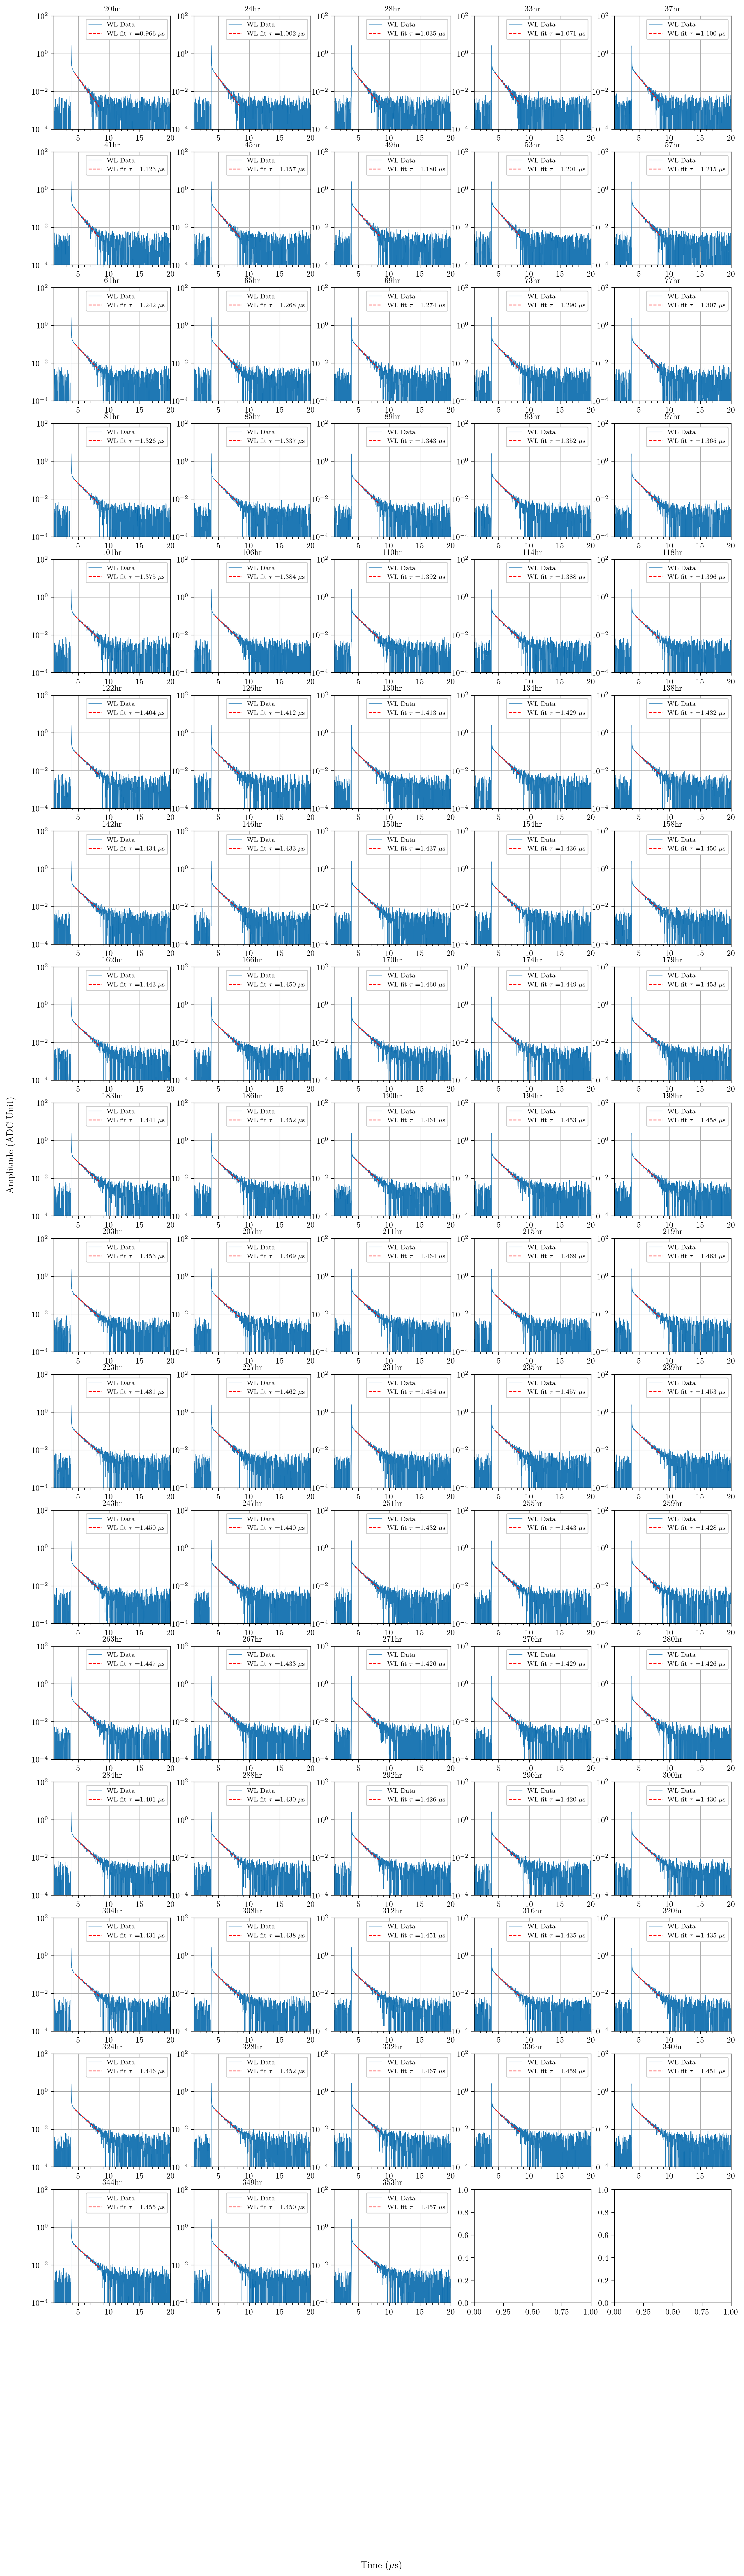

In [19]:
# Make plots for all datasets
nrows = (len(files)+4)//5
fig, axs = plt.subplots(nrows, 5, sharex=False, sharey=False)
fig.set_size_inches(15, 3*nrows)
for i, f in enumerate(files):
    if data_scint[i][-1]['sum_wf_nofs'].shape[0]>0:
        axs[i//5, i%5].plot(
            data_scint[i][-1]['time_sub'],
            data_scint[i][-1]['sum_wf_sub_nofs'],
            label='WL Data', color='C0', linewidth=0.5)
        mask = (data_scint[i][-1]['time_sub']>data_scint[i][-1]['fit_range'][0]) & (data_scint[i][-1]['time_sub']<data_scint[i][-1]['fit_range'][1])
        
        # simple exponential fit to windowless
        axs[i//5, i%5].plot(
            data_scint[i][-1]['time_sub'][mask],
            exp_func(data_scint[i][-1]['time_sub'][mask], *data_scint[i][-1]['pars']),
            label=r'WL fit $\tau=${:.3f} $\mu $s'.format(data_scint[i][-1]['pars'][1]), color='r', linestyle='--', linewidth=1)

        axs[i//5, i%5].legend(loc='upper right',ncol=1)
        axs[i//5, i%5].set_xlim(1, 20)
        axs[i//5, i%5].set_ylim(1e-4, 1e2)
        axs[i//5, i%5].set_yscale('log')
        axs[i//5, i%5].minorticks_on()
        axs[i//5, i%5].grid()
        axs[i//5, i%5].set_title(f'{hr_from_getter[i]:.0f}hr')
fig.supxlabel(r'Time ($\mu$s)', y=0.02)
fig.supylabel(r'Amplitude (ADC Unit)', x=0.07)

# Triplet lifetime evolution

Text(0.5, 0, 'Purification Time [hr]')

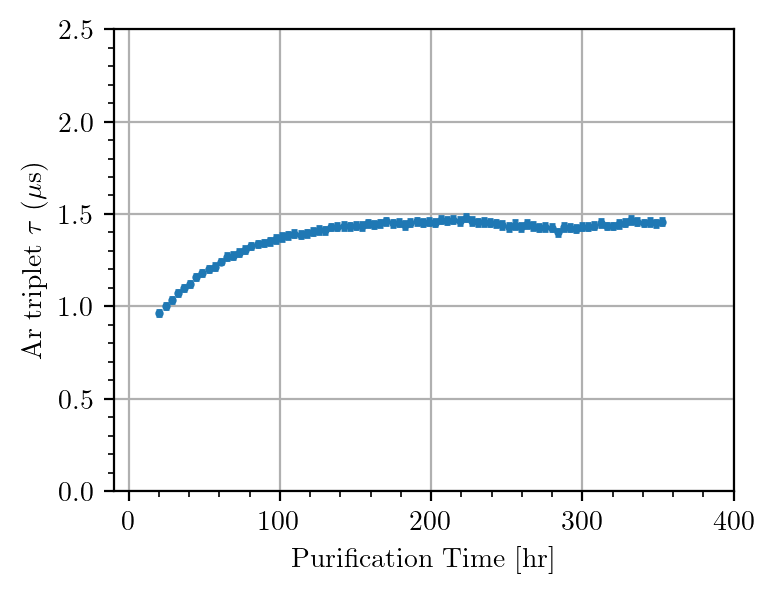

In [20]:
plt.errorbar(
	hr_from_getter,
	[data_scint[j][-1]['pars'][1] for j in range(len(files))],
	yerr=[func.error_distance(df=2, sigma=1)*np.sqrt(data_scint[j][-1]['cov'][1,1]) for j in range(len(files))],
	linestyle='', linewidth=1, fmt='o', markersize=2, capsize=1
)
plt.ylabel(r'Ar triplet $\tau$ ($\mu$s)')
plt.ylim(0,2.5)
plt.minorticks_on()
plt.grid()
plt.xlim(-10,400)
plt.xlabel('Purification Time [hr]')